In [ ]:
import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [2]:
import os

print(os.listdir('/content'))

['.config', '.ipynb_checkpoints', 'your_sepsis_dataset.zip.zip', 'archive (1).zip', 'sample_data']


In [3]:
import zipfile
import os

zip_files = [
    '/content/your_sepsis_dataset.zip.zip',
    '/content/archive (1).zip'
]

for zip_path in zip_files:
    print("\n" + "="*60)
    print("FILE:", os.path.basename(zip_path))

    with zipfile.ZipFile(zip_path, 'r') as z:
        files = z.namelist()
        print("Number of files:", len(files))
        print("First 15 files:")
        for f in files[:15]:
            print("  ", f)


FILE: your_sepsis_dataset.zip.zip


BadZipFile: File is not a zip file

In [4]:
import zipfile
import os

zip_path = '/content/archive (1).zip'

print("Checking:", zip_path)

with zipfile.ZipFile(zip_path, 'r') as z:
    files = z.namelist()

    print("Number of files:", len(files))
    print("\nFirst 20 files:")

    for f in files[:20]:
        print(f)


Checking: /content/archive (1).zip
Number of files: 40342

First 20 files:
Dataset.csv
LICENSE.txt
SHA256SUMS.txt
physionet_challenge_2019_ccm_manuscript.pdf
training_setA/training/p000001.psv
training_setA/training/p000002.psv
training_setA/training/p000003.psv
training_setA/training/p000004.psv
training_setA/training/p000005.psv
training_setA/training/p000006.psv
training_setA/training/p000007.psv
training_setA/training/p000008.psv
training_setA/training/p000009.psv
training_setA/training/p000010.psv
training_setA/training/p000011.psv
training_setA/training/p000012.psv
training_setA/training/p000013.psv
training_setA/training/p000014.psv
training_setA/training/p000015.psv
training_setA/training/p000016.psv


In [5]:
import zipfile
import pandas as pd

zip_path = '/content/archive (1).zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    df = pd.read_csv(z.open('Dataset.csv'))

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

OSError: [Errno 22] Invalid argument

In [6]:
import zipfile
import os
import pandas as pd

zip_path = '/content/archive (1).zip'
csv_path = '/content/Dataset.csv'

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('Dataset.csv') as source:
        with open(csv_path, 'wb') as target:
            target.write(source.read())

print("Dataset.csv extracted successfully!")
print("File size:", os.path.getsize(csv_path) / (1024**2), "MB")

OSError: [Errno 22] Invalid argument

In [7]:
import zipfile
import pandas as pd

zip_path = '/content/archive (1).zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    patient_file = 'training_setA/training/p000001.psv'
    z.extract(patient_file, '/content/test_patient')

df_test = pd.read_csv(
    '/content/test_patient/training_setA/training/p000001.psv',
    sep='|'
)

print("Shape:", df_test.shape)
print("\nColumns:")
print(df_test.columns.tolist())

display(df_test.head())

Shape: (54, 41)

Columns:
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel']


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0


In [8]:
# Basic patient analysis

print("Number of ICU hours:", len(df_test))

print("\nSepsis label distribution:")
print(df_test["SepsisLabel"].value_counts())

print("\nSepsis hours:")
print(df_test[df_test["SepsisLabel"] == 1]["ICULOS"].tolist())

print("\nMissing values (%):")
missing = (df_test.isnull().mean() * 100).sort_values(ascending=False)
print(missing.head(15))

Number of ICU hours: 54

Sepsis label distribution:
SepsisLabel
0    54
Name: count, dtype: int64

Sepsis hours:
[]

Missing values (%):
EtCO2               100.000000
DBP                 100.000000
TroponinI           100.000000
Fibrinogen          100.000000
Unit1               100.000000
Unit2               100.000000
PTT                 100.000000
Bilirubin_direct    100.000000
Lactate             100.000000
Bilirubin_total      98.148148
AST                  98.148148
Alkalinephos         98.148148
Platelets            96.296296
Phosphate            96.296296
Magnesium            96.296296
dtype: float64


In [9]:
import zipfile
import pandas as pd

zip_path = '/content/archive (1).zip'

sepsis_patients = []
total_patients = 0

with zipfile.ZipFile(zip_path, 'r') as z:
    patient_files = [
        f for f in z.namelist()
        if f.startswith('training_setA/training/') and f.endswith('.psv')
    ]

    print("Patients found:", len(patient_files))

    for i, file in enumerate(patient_files):
        df = pd.read_csv(z.open(file), sep='|')

        total_patients += 1

        if df['SepsisLabel'].eq(1).any():
            sepsis_patients.append(file)

        # Stop after checking 2,000 patients for now
        if total_patients >= 2000:
            break

print("\nPatients checked:", total_patients)
print("Sepsis patients found:", len(sepsis_patients))

print("\nFirst 10 sepsis patients:")
print(sepsis_patients[:10])

Patients found: 20336

Patients checked: 2000
Sepsis patients found: 184

First 10 sepsis patients:
['training_setA/training/p000009.psv', 'training_setA/training/p000011.psv', 'training_setA/training/p000015.psv', 'training_setA/training/p000018.psv', 'training_setA/training/p000022.psv', 'training_setA/training/p000028.psv', 'training_setA/training/p000034.psv', 'training_setA/training/p000042.psv', 'training_setA/training/p000053.psv', 'training_setA/training/p000056.psv']


In [10]:
import zipfile
import pandas as pd

zip_path = '/content/archive (1).zip'

all_data = []

with zipfile.ZipFile(zip_path, 'r') as z:
    patient_files = [
        f for f in z.namelist()
        if f.startswith('training_setA/training/') and f.endswith('.psv')
    ][:2000]

    for i, file in enumerate(patient_files):

        df = pd.read_csv(z.open(file), sep='|')

        # Add patient identifier
        df['PatientID'] = file.split('/')[-1].replace('.psv', '')

        all_data.append(df)

        if (i + 1) % 500 == 0:
            print(f"Processed {i + 1} patients...")

# Combine all patients
data = pd.concat(all_data, ignore_index=True)

print("\nDataset created!")
print("Shape:", data.shape)

print("\nNumber of patients:", data['PatientID'].nunique())

print("\nSepsis distribution:")
print(data['SepsisLabel'].value_counts())

print("\nSepsis percentage:")
print(data['SepsisLabel'].mean() * 100)

Processed 500 patients...
Processed 1000 patients...
Processed 1500 patients...
Processed 2000 patients...

Dataset created!
Shape: (78083, 42)

Number of patients: 2000

Sepsis distribution:
SepsisLabel
0    76323
1     1760
Name: count, dtype: int64

Sepsis percentage:
2.2540117567204128


In [11]:
# Basic dataset overview

print("Dataset shape:", data.shape)

print("\nData types:")
print(data.dtypes.value_counts())

print("\nMissing values (%):")
missing = (data.isnull().mean() * 100).sort_values(ascending=False)

display(missing.to_frame("Missing %").head(20))

print("\nSepsis distribution:")
display(data["SepsisLabel"].value_counts())

print("\nUnique patients:", data["PatientID"].nunique())

print("\nICU hours:")
print("Minimum:", data["ICULOS"].min())
print("Maximum:", data["ICULOS"].max())
print("Average:", data["ICULOS"].mean())

Dataset shape: (78083, 42)

Data types:
float64    38
int64       3
object      1
Name: count, dtype: int64

Missing values (%):


,Missing %
EtCO2,100.000000
TroponinI,99.860405
Bilirubin_direct,99.836072
Fibrinogen,99.129132
Bilirubin_total,98.869152
Alkalinephos,98.604050
AST,98.580997
Lactate,96.410230
Calcium,95.158997
PTT,95.048858



Sepsis distribution:


,count
SepsisLabel,
0,76323
1,1760



Unique patients: 2000

ICU hours:
Minimum: 1
Maximum: 283
Average: 27.779631930125635


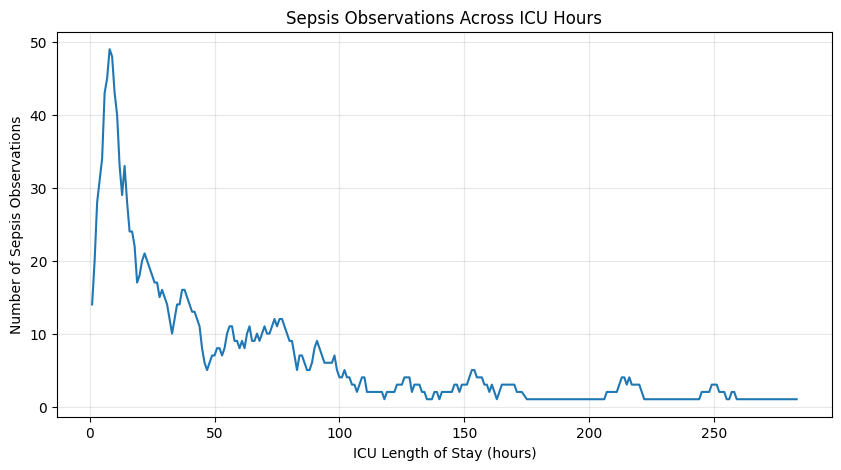

First ICU hour with a sepsis observation: 1
ICU hour with most sepsis observations: 8
Maximum sepsis observations in one hour: 49


In [12]:
import matplotlib.pyplot as plt

# Sepsis cases by ICU hour
sepsis_by_hour = (
    data[data["SepsisLabel"] == 1]
    .groupby("ICULOS")
    .size()
)

plt.figure(figsize=(10, 5))
plt.plot(sepsis_by_hour.index, sepsis_by_hour.values)
plt.xlabel("ICU Length of Stay (hours)")
plt.ylabel("Number of Sepsis Observations")
plt.title("Sepsis Observations Across ICU Hours")
plt.grid(alpha=0.3)
plt.show()

# Summary
print("First ICU hour with a sepsis observation:",
      sepsis_by_hour.index.min())

print("ICU hour with most sepsis observations:",
      sepsis_by_hour.idxmax())

print("Maximum sepsis observations in one hour:",
      sepsis_by_hour.max())

In [13]:
# Sort patient data chronologically
data = data.sort_values(["PatientID", "ICULOS"]).copy()

# Clinical variables for which trends are useful
trend_features = [
    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "Resp",
    "WBC",
    "Lactate",
    "Creatinine",
    "Glucose"
]

# Create previous-hour values and changes
for col in trend_features:
    if col in data.columns:
        data[f"{col}_change"] = (
            data.groupby("PatientID")[col].diff()
        )

# Create 3-hour rolling averages
for col in trend_features:
    if col in data.columns:
        data[f"{col}_rolling3"] = (
            data.groupby("PatientID")[col]
            .transform(lambda x: x.rolling(3, min_periods=1).mean())
        )

print("Feature engineering completed!")

print("New dataset shape:", data.shape)

print("\nNew trend features:")
print([
    c for c in data.columns
    if "_change" in c or "_rolling3" in c
])

Feature engineering completed!
New dataset shape: (78083, 62)

New trend features:
['HR_change', 'O2Sat_change', 'Temp_change', 'SBP_change', 'MAP_change', 'Resp_change', 'WBC_change', 'Lactate_change', 'Creatinine_change', 'Glucose_change', 'HR_rolling3', 'O2Sat_rolling3', 'Temp_rolling3', 'SBP_rolling3', 'MAP_rolling3', 'Resp_rolling3', 'WBC_rolling3', 'Lactate_rolling3', 'Creatinine_rolling3', 'Glucose_rolling3']


In [14]:
from sklearn.model_selection import train_test_split

# Get unique patients
patients = data["PatientID"].unique()

# Split patients
train_patients, test_patients = train_test_split(
    patients,
    test_size=0.20,
    random_state=42
)

train_data = data[data["PatientID"].isin(train_patients)].copy()
test_data = data[data["PatientID"].isin(test_patients)].copy()

print("Training patients:", len(train_patients))
print("Testing patients:", len(test_patients))

print("\nTraining observations:", len(train_data))
print("Testing observations:", len(test_data))

print("\nTraining sepsis rate:",
      train_data["SepsisLabel"].mean())

print("Testing sepsis rate:",
      test_data["SepsisLabel"].mean())

Training patients: 1600
Testing patients: 400

Training observations: 62988
Testing observations: 15095

Training sepsis rate: 0.02170254651679685
Testing sepsis rate: 0.02603511096389533


In [15]:
from sklearn.impute import SimpleImputer

# Columns we want to use
exclude_cols = [
    "PatientID",
    "SepsisLabel"
]

feature_cols = [
    c for c in data.columns
    if c not in exclude_cols
]

# Keep numeric columns only
feature_cols = [
    c for c in feature_cols
    if train_data[c].dtype != "object"
]

X_train = train_data[feature_cols]
X_test = test_data[feature_cols]

y_train = train_data["SepsisLabel"]
y_test = test_data["SepsisLabel"]

# Median imputation
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

print("Number of features:", len(feature_cols))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Number of features: 60
X_train shape: (62988, 59)
X_test shape: (15095, 59)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['EtCO2']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['EtCO2']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [16]:
# Remove features that are completely missing in the training set

valid_features = [
    col for col in feature_cols
    if train_data[col].notna().any()
]

removed_features = [
    col for col in feature_cols
    if col not in valid_features
]

print("Removed completely missing features:")
print(removed_features)

print("\nFeatures remaining:", len(valid_features))

# Recreate X using valid features
X_train_raw = train_data[valid_features]
X_test_raw = test_data[valid_features]

# Impute using training-set medians
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train_raw)
X_test = imputer.transform(X_test_raw)

print("\nFinal X_train shape:", X_train.shape)
print("Final X_test shape:", X_test.shape)

Removed completely missing features:
['EtCO2']

Features remaining: 59

Final X_train shape: (62988, 59)
Final X_test shape: (15095, 59)


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score
)

# Train baseline model
model_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train, y_train)

# Predictions
y_pred = model_lr.predict(X_test)
y_prob = model_lr.predict_proba(X_test)[:, 1]

# Metrics
print("=== Logistic Regression Results ===\n")

print(classification_report(
    y_test,
    y_pred,
    digits=3
))

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))
print("PR-AUC:", round(average_precision_score(y_test, y_prob), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

=== Logistic Regression Results ===

              precision    recall  f1-score   support

           0      0.983     0.795     0.879     14702
           1      0.060     0.491     0.107       393

    accuracy                          0.787     15095
   macro avg      0.522     0.643     0.493     15095
weighted avg      0.959     0.787     0.859     15095

ROC-AUC: 0.697
PR-AUC: 0.084

Confusion Matrix:
[[11685  3017]
 [  200   193]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score
)

# Random Forest
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

model_rf.fit(X_train, y_train)

# Predictions
y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===\n")

print(classification_report(
    y_test,
    y_pred_rf,
    digits=3
))

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 3))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_rf), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest Results ===

              precision    recall  f1-score   support

           0      0.978     0.967     0.972     14702
           1      0.127     0.181     0.149       393

    accuracy                          0.946     15095
   macro avg      0.552     0.574     0.561     15095
weighted avg      0.956     0.946     0.951     15095

ROC-AUC: 0.697
PR-AUC: 0.086

Confusion Matrix:
[[14212   490]
 [  322    71]]


In [19]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.96, 0.05)

results = []

for threshold in thresholds:

    predictions = (y_prob_rf >= threshold).astype(int)

    recall = recall_score(y_test, predictions, zero_division=0)
    precision = precision_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    alerts = predictions.sum()
    alert_rate = alerts / len(y_test) * 100

    results.append({
        "Threshold": round(threshold, 2),
        "Recall": round(recall, 3),
        "Precision": round(precision, 3),
        "F1": round(f1, 3),
        "Alerts": alerts,
        "Alert Rate %": round(alert_rate, 2)
    })

threshold_results = pd.DataFrame(results)

display(threshold_results)

,Threshold,Recall,Precision,F1,Alerts,Alert Rate %
0,0.05,0.985,0.028,0.054,13811,91.49
1,0.10,0.931,0.035,0.067,10541,69.83
2,0.15,0.824,0.038,0.072,8567,56.75
3,0.20,0.705,0.040,0.076,6926,45.88
4,0.25,0.575,0.042,0.079,5349,35.44
5,0.30,0.463,0.050,0.090,3652,24.19
6,0.35,0.354,0.059,0.101,2363,15.65
7,0.40,0.295,0.075,0.119,1557,10.31
8,0.45,0.234,0.096,0.136,960,6.36
9,0.50,0.181,0.127,0.149,561,3.72


In [20]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score
)

# Calculate class imbalance
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()
scale_pos_weight = negative / positive

print("Scale positive weight:", round(scale_pos_weight, 2))

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = model_xgb.predict(X_test)
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBoost Results ===\n")

print(classification_report(
    y_test,
    y_pred_xgb,
    digits=3
))

print("ROC-AUC:",
      round(roc_auc_score(y_test, y_prob_xgb), 3))

print("PR-AUC:",
      round(average_precision_score(y_test, y_prob_xgb), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Scale positive weight: 45.08

=== XGBoost Results ===

              precision    recall  f1-score   support

           0      0.980     0.940     0.959     14702
           1      0.107     0.270     0.153       393

    accuracy                          0.922     15095
   macro avg      0.543     0.605     0.556     15095
weighted avg      0.957     0.922     0.938     15095

ROC-AUC: 0.708
PR-AUC: 0.098

Confusion Matrix:
[[13819   883]
 [  287   106]]


In [21]:
# Compare key clinical indicators between sepsis and non-sepsis observations

key_features = [
    "HR", "O2Sat", "Temp", "SBP", "MAP", "Resp",
    "WBC", "Lactate", "Creatinine", "Glucose",
    "Hgb", "Platelets", "BUN"
]

driver_summary = data.groupby("SepsisLabel")[key_features].mean().T

driver_summary.columns = ["Non-Sepsis", "Sepsis"]

driver_summary["Difference %"] = (
    (driver_summary["Sepsis"] - driver_summary["Non-Sepsis"])
    / driver_summary["Non-Sepsis"].abs()
) * 100

driver_summary = driver_summary.sort_values(
    "Difference %",
    key=abs,
    ascending=False
)

display(driver_summary.round(2))

,Non-Sepsis,Sepsis,Difference %
Creatinine,1.42,1.85,30.24
BUN,24.25,30.52,25.85
WBC,11.98,13.50,12.66
Lactate,2.53,2.83,12.22
Resp,18.70,20.60,10.16
HR,85.18,91.12,6.97
Hgb,10.61,9.91,-6.59
Platelets,199.30,188.71,-5.32
Glucose,133.40,130.52,-2.16
MAP,78.73,77.06,-2.13


In [22]:
import numpy as np
import pandas as pd

key_features = [
    "HR", "O2Sat", "Temp", "SBP", "MAP", "Resp",
    "WBC", "Lactate", "Creatinine", "Glucose",
    "Hgb", "Platelets", "BUN"
]

# Median is more robust than mean for clinical data with outliers
driver_summary = data.groupby("SepsisLabel")[key_features].median().T

driver_summary.columns = ["Non-Sepsis", "Sepsis"]

driver_summary["% Difference"] = (
    (driver_summary["Sepsis"] - driver_summary["Non-Sepsis"])
    / driver_summary["Non-Sepsis"].abs()
) * 100

driver_summary["Absolute Difference"] = driver_summary["% Difference"].abs()

driver_summary = driver_summary.sort_values(
    "Absolute Difference",
    ascending=False
).drop(columns="Absolute Difference")

display(driver_summary.round(2))

,Non-Sepsis,Sepsis,% Difference
BUN,18.00,28.0,55.56
Creatinine,0.90,1.3,44.44
Resp,18.00,20.0,11.11
Platelets,182.00,163.0,-10.44
WBC,10.70,11.6,8.41
HR,84.00,90.0,7.14
Hgb,10.40,9.8,-5.77
Lactate,1.80,1.7,-5.56
MAP,77.00,75.0,-2.60
SBP,118.00,116.0,-1.69


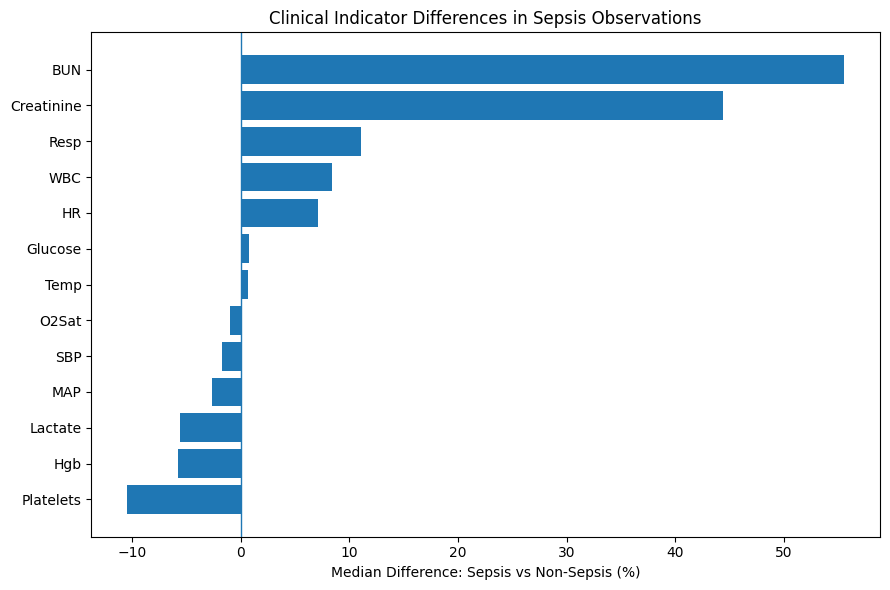

In [23]:
import matplotlib.pyplot as plt

plot_data = driver_summary["% Difference"].sort_values()

plt.figure(figsize=(9, 6))
plt.barh(plot_data.index, plot_data.values)
plt.axvline(0, linewidth=1)
plt.xlabel("Median Difference: Sepsis vs Non-Sepsis (%)")
plt.title("Clinical Indicator Differences in Sepsis Observations")
plt.tight_layout()
plt.show()

In [24]:
# Add model risk score to test data
analysis_data = test_data.copy()

analysis_data["RiskScore"] = y_prob_rf

# Create practical risk segments
analysis_data["RiskSegment"] = pd.cut(
    analysis_data["RiskScore"],
    bins=[-0.01, 0.30, 0.50, 1.00],
    labels=["Low Risk", "Moderate Risk", "High Risk"]
)

# Segment summary
segment_summary = (
    analysis_data
    .groupby("RiskSegment", observed=True)
    .agg(
        Observations=("SepsisLabel", "size"),
        SepsisCases=("SepsisLabel", "sum"),
        Actual_Sepsis_Rate=("SepsisLabel", "mean"),
        Avg_RiskScore=("RiskScore", "mean")
    )
)

segment_summary["Actual_Sepsis_Rate"] *= 100

display(segment_summary.round(3))

,Observations,SepsisCases,Actual_Sepsis_Rate,Avg_RiskScore
RiskSegment,,,,
Low Risk,11443,211,1.844,0.144
Moderate Risk,3091,111,3.591,0.375
High Risk,561,71,12.656,0.590


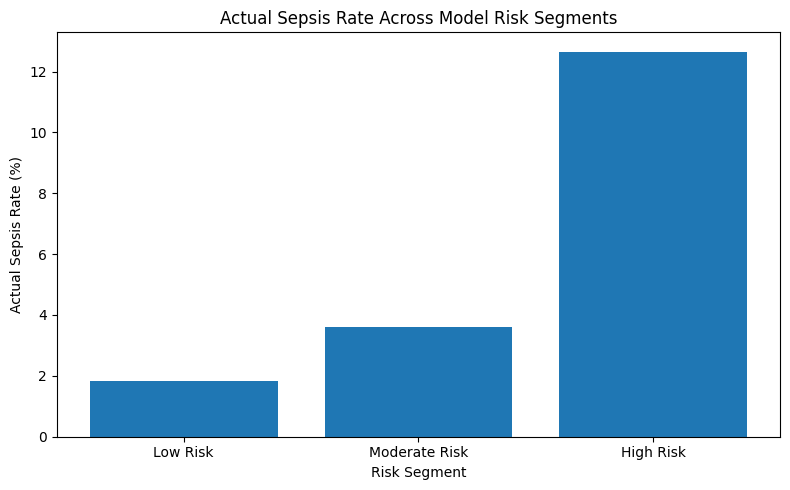

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    segment_summary.index.astype(str),
    segment_summary["Actual_Sepsis_Rate"]
)

plt.ylabel("Actual Sepsis Rate (%)")
plt.xlabel("Risk Segment")
plt.title("Actual Sepsis Rate Across Model Risk Segments")

plt.tight_layout()
plt.show()

In [26]:
# Executive KPI summary

total_patients = data["PatientID"].nunique()
total_observations = len(data)

sepsis_patients = (
    data.groupby("PatientID")["SepsisLabel"]
    .max()
    .sum()
)

sepsis_observations = data["SepsisLabel"].sum()

patient_sepsis_rate = sepsis_patients / total_patients * 100
observation_sepsis_rate = sepsis_observations / total_observations * 100

# Alert metrics at selected thresholds
thresholds_to_compare = [0.30, 0.40, 0.50]

kpi_rows = []

for threshold in thresholds_to_compare:
    predictions = (y_prob_rf >= threshold).astype(int)

    alerts = predictions.sum()
    true_positives = ((predictions == 1) & (y_test.values == 1)).sum()

    recall = true_positives / (y_test == 1).sum()
    precision = (
        true_positives / alerts
        if alerts > 0 else 0
    )

    kpi_rows.append({
        "Alert Threshold": threshold,
        "Recall %": recall * 100,
        "Precision %": precision * 100,
        "Alerts": alerts,
        "Alert Rate %": alerts / len(y_test) * 100
    })

kpi_table = pd.DataFrame(kpi_rows)

print("========== EXECUTIVE KPI SUMMARY ==========\n")

print("Patients analyzed:", total_patients)
print("ICU observations analyzed:", f"{total_observations:,}")
print("Patients with sepsis:", int(sepsis_patients))
print("Patient-level sepsis rate:", round(patient_sepsis_rate, 2), "%")
print("Patient-hour sepsis observation rate:",
      round(observation_sepsis_rate, 2), "%")

print("\n========== ALERT TRADE-OFF ==========\n")

display(kpi_table.round(2))

========== EXECUTIVE KPI SUMMARY ==========

Patients analyzed: 2000
ICU observations analyzed: 78,083
Patients with sepsis: 184
Patient-level sepsis rate: 9.2 %
Patient-hour sepsis observation rate: 2.25 %

========== ALERT TRADE-OFF ==========



,Alert Threshold,Recall %,Precision %,Alerts,Alert Rate %
0,0.3,46.31,4.98,3652,24.19
1,0.4,29.52,7.45,1557,10.31
2,0.5,18.07,12.66,561,3.72


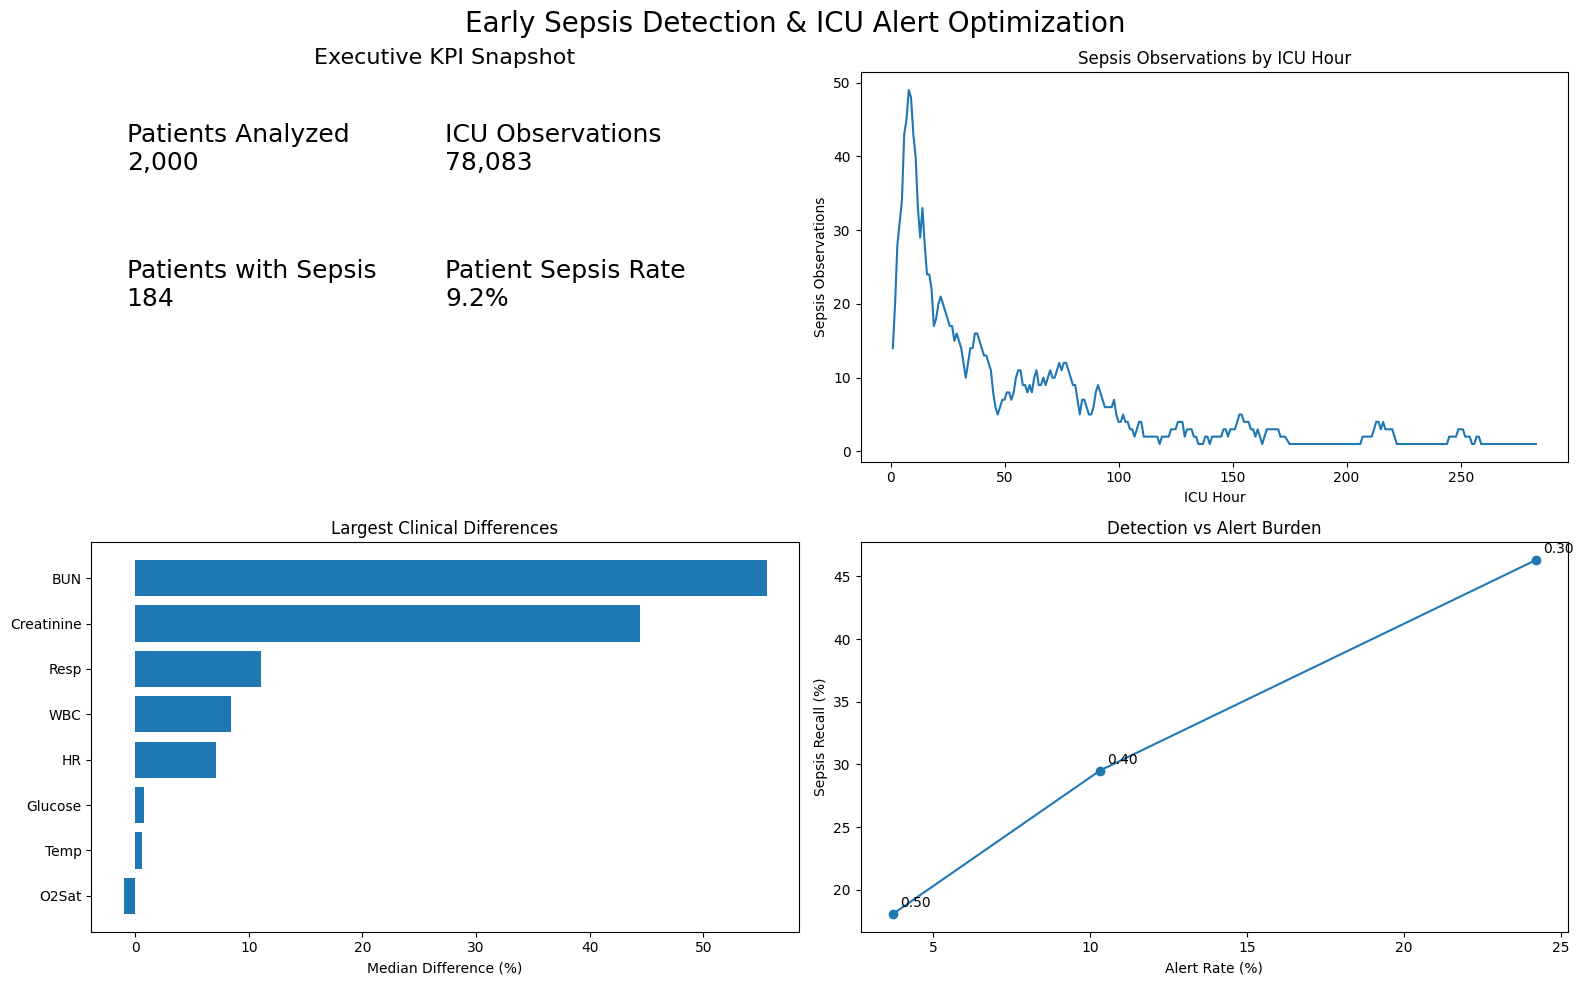

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- KPI calculations ----------

total_patients = data["PatientID"].nunique()
total_observations = len(data)

sepsis_patients = data.groupby("PatientID")["SepsisLabel"].max().sum()
patient_sepsis_rate = sepsis_patients / total_patients * 100

# ---------- 1. Sepsis observations over ICU time ----------

sepsis_by_hour = (
    data[data["SepsisLabel"] == 1]
    .groupby("ICULOS")
    .size()
)

# ---------- 2. Top clinical differences ----------

driver_plot = driver_summary["% Difference"].sort_values()

# ---------- 3. Alert trade-off ----------

thresholds = [0.30, 0.40, 0.50]

recalls = []
alert_rates = []

for threshold in thresholds:
    predictions = (y_prob_rf >= threshold).astype(int)

    recalls.append(
        ((predictions == 1) & (y_test.values == 1)).sum()
        / (y_test.values == 1).sum()
        * 100
    )

    alert_rates.append(
        predictions.mean() * 100
    )

# ---------- Dashboard ----------

fig = plt.figure(figsize=(16, 10))

# KPI area
ax1 = plt.subplot(2, 2, 1)

ax1.axis("off")

ax1.text(
    0.05, 0.75,
    f"Patients Analyzed\n{total_patients:,}",
    fontsize=18
)

ax1.text(
    0.50, 0.75,
    f"ICU Observations\n{total_observations:,}",
    fontsize=18
)

ax1.text(
    0.05, 0.40,
    f"Patients with Sepsis\n{int(sepsis_patients):,}",
    fontsize=18
)

ax1.text(
    0.50, 0.40,
    f"Patient Sepsis Rate\n{patient_sepsis_rate:.1f}%",
    fontsize=18
)

ax1.set_title(
    "Executive KPI Snapshot",
    fontsize=16
)

# Sepsis timing
ax2 = plt.subplot(2, 2, 2)

ax2.plot(
    sepsis_by_hour.index,
    sepsis_by_hour.values
)

ax2.set_title("Sepsis Observations by ICU Hour")
ax2.set_xlabel("ICU Hour")
ax2.set_ylabel("Sepsis Observations")

# Clinical drivers
ax3 = plt.subplot(2, 2, 3)

top_drivers = driver_plot.tail(8)

ax3.barh(
    top_drivers.index,
    top_drivers.values
)

ax3.set_title("Largest Clinical Differences")
ax3.set_xlabel("Median Difference (%)")

# Alert trade-off
ax4 = plt.subplot(2, 2, 4)

ax4.plot(
    alert_rates,
    recalls,
    marker="o"
)

for x, y, t in zip(alert_rates, recalls, thresholds):
    ax4.annotate(
        f"{t:.2f}",
        (x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax4.set_title("Detection vs Alert Burden")
ax4.set_xlabel("Alert Rate (%)")
ax4.set_ylabel("Sepsis Recall (%)")

plt.suptitle(
    "Early Sepsis Detection & ICU Alert Optimization",
    fontsize=20
)

plt.tight_layout()
plt.show()